# 02 — Mixed Precision Training (FP16 + FP32)
This notebook trains the same ResNet-18 on CIFAR-10 using Automatic Mixed Precision (AMP).
Most operations run in FP16 (half precision) to save memory and speed up training,
while critical operations stay in FP32 to maintain numerical stability.
We compare the results against the baseline model.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.cuda.amp import GradScaler, autocast
import time
import os
import json
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
print(f"Mixed Precision supported: {torch.cuda.is_available()}")

Training on: cuda
Mixed Precision supported: True


In [2]:
# Exact same transforms and loaders as baseline — fair comparison
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle=False, num_workers=2
)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

Training samples : 50000
Test samples     : 10000


In [3]:
# Exact same architecture as baseline
model = resnet18(pretrained=False)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                        stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)
print("Model ready.")

d:\quantization_project\edge-ai\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\quantization_project\edge-ai\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model ready.


In [4]:
def train_amp(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # --- This is the key difference from baseline ---
        with autocast():                          # FP16 math happens here
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()             # Scaled gradients
        scaler.step(optimizer)                    # Optimizer step
        scaler.update()                           # Update scaler
        # ------------------------------------------------

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    accuracy = 100.0 * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, accuracy

In [5]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    accuracy = 100.0 * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, accuracy

In [6]:
NUM_EPOCHS = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1,
                      momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = GradScaler()   # <-- This is new, manages FP16 scaling

train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("Starting mixed precision training...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_amp(model, train_loader,
                                      optimizer, criterion, scaler)
    test_loss, test_acc   = evaluate(model, test_loader, criterion)
    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

total_time = time.time() - start_time
print(f"\nTotal training time: {total_time/60:.2f} minutes")

Starting mixed precision training...



C:\Users\abhya\AppData\Local\Temp\ipykernel_1960\3250186469.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()   # <-- This is new, manages FP16 scaling
C:\Users\abhya\AppData\Local\Temp\ipykernel_1960\587665916.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                          # FP16 math happens here


Epoch [01/10] Train Loss: 1.9496 | Train Acc: 29.79% | Test Loss: 1.5950 | Test Acc: 40.76%
Epoch [02/10] Train Loss: 1.4195 | Train Acc: 47.88% | Test Loss: 1.2956 | Test Acc: 52.85%
Epoch [03/10] Train Loss: 1.0899 | Train Acc: 60.87% | Test Loss: 1.1190 | Test Acc: 60.20%
Epoch [04/10] Train Loss: 0.8523 | Train Acc: 69.99% | Test Loss: 0.8474 | Test Acc: 70.85%
Epoch [05/10] Train Loss: 0.6803 | Train Acc: 76.30% | Test Loss: 0.7084 | Test Acc: 75.01%
Epoch [06/10] Train Loss: 0.5653 | Train Acc: 80.43% | Test Loss: 0.5881 | Test Acc: 79.36%
Epoch [07/10] Train Loss: 0.4756 | Train Acc: 83.53% | Test Loss: 0.5174 | Test Acc: 82.39%
Epoch [08/10] Train Loss: 0.3946 | Train Acc: 86.36% | Test Loss: 0.4501 | Test Acc: 84.42%
Epoch [09/10] Train Loss: 0.3220 | Train Acc: 89.02% | Test Loss: 0.3755 | Test Acc: 87.11%
Epoch [10/10] Train Loss: 0.2738 | Train Acc: 90.62% | Test Loss: 0.3552 | Test Acc: 88.32%

Total training time: 7.37 minutes


In [7]:
os.makedirs("saved_models", exist_ok=True)
torch.save(model.state_dict(), "saved_models/mixed_precision.pth")
print("Model saved to saved_models/mixed_precision.pth")

metrics = {
    "train_losses"  : train_losses,
    "test_losses"   : test_losses,
    "train_accs"    : train_accs,
    "test_accs"     : test_accs,
    "total_time"    : total_time,
    "final_test_acc": test_accs[-1]
}
os.makedirs("metrics", exist_ok=True)
with open("metrics/mixed_precision_metrics.json", "w") as f:
    json.dump(metrics, f)
print("Metrics saved to metrics/mixed_precision_metrics.json")

Model saved to saved_models/mixed_precision.pth
Metrics saved to metrics/mixed_precision_metrics.json


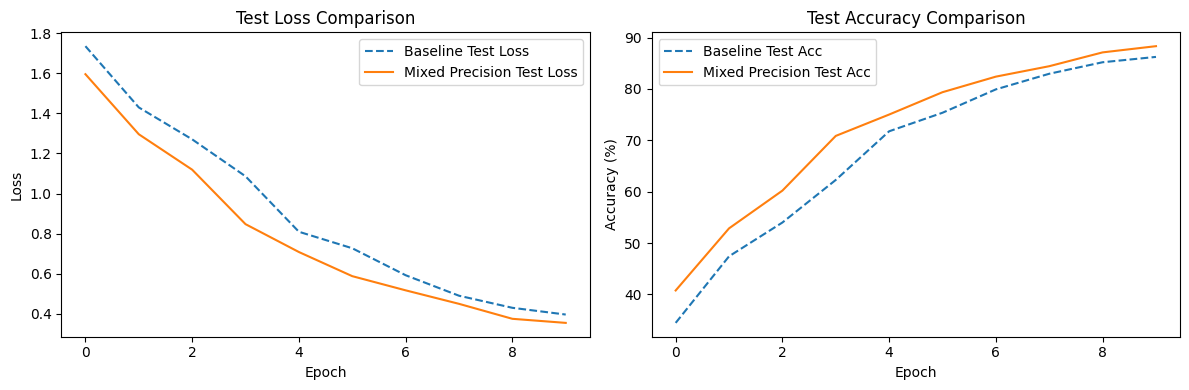


--- Results Summary ---
Baseline       Test Accuracy : 86.23%
Mixed Precision Test Accuracy: 88.32%
Baseline       Training Time : 9.31 min
Mixed Precision Training Time: 7.37 min


In [8]:
# Load baseline metrics for comparison
with open("metrics/baseline_metrics.json", "r") as f:
    baseline = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss comparison
ax1.plot(baseline["test_losses"], label="Baseline Test Loss",        linestyle="--")
ax1.plot(test_losses,             label="Mixed Precision Test Loss")
ax1.set_title("Test Loss Comparison")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Accuracy comparison
ax2.plot(baseline["test_accs"], label="Baseline Test Acc",        linestyle="--")
ax2.plot(test_accs,             label="Mixed Precision Test Acc")
ax2.set_title("Test Accuracy Comparison")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()

plt.tight_layout()
plt.savefig("metrics/mixed_precision_curves.png")
plt.show()

print(f"\n--- Results Summary ---")
print(f"Baseline       Test Accuracy : {baseline['final_test_acc']:.2f}%")
print(f"Mixed Precision Test Accuracy: {test_accs[-1]:.2f}%")
print(f"Baseline       Training Time : {baseline['total_time']/60:.2f} min")
print(f"Mixed Precision Training Time: {total_time/60:.2f} min")